[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/sorbonnescai/2026_bootcamp_spatial/blob/main/projects/project1_land_cover_modis.ipynb)

# Project 1 - Classification de l'occupation des sols avec MODIS Terra-Aqua

# **Getting started with MODIS reflectance (NBAR) and Land Cover data**


## Imports

In [ ]:
! pip install cartopy # If cartopy is not installed yet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 13.4 MB/s eta 0:00:00


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Plot Map
import cartopy.crs as ccrs
from matplotlib.colors import ListedColormap, BoundaryNorm

In [ ]:
# Importing reflectance bands and land class MODIS data

import gdown

file_id_nbar = "1HncVKmap1UZhjZhtebx4rIiWpHQ2IBEX"
path_nbar = gdown.download(id = file_id_nbar, output = "MODIS_reflectancebands_0.25x0.25_2019.nc", quiet=False)

file_id_land_class = "1INF43q2DpFtGV1MJvh8wllWnOmFa0O7e"
path_land_class = gdown.download(id = file_id_land_class, output = "MODIS_landcover_0.25x0.25_2019.nc", quiet=False)

Downloading...
From: https://drive.google.com/uc?id=1HncVKmap1UZhjZhtebx4rIiWpHQ2IBEX
To: /content/MODIS_reflectancebands_0.25x0.25_2019.nc
100%|██████████| 29.1M/29.1M [00:00<00:00, 78.1MB/s]
Downloading...
From: https://drive.google.com/uc?id=1INF43q2DpFtGV1MJvh8wllWnOmFa0O7e
To: /content/MODIS_landcover_0.25x0.25_2019.nc
100%|██████████| 8.32M/8.32M [00:00<00:00, 36.7MB/s]


## Load Data

Datasets provided for this project (0.25x0.25° grids) :

    - Nadir Bidirectional reflectance distribution function Adjusted  Reflectances from MODIS satellite measurements (8-day average, from 2019-12-24 to 2019-12-31)

    - Global Land Cover type from MODIS (official product) for 2019


In [ ]:
# TODO: load MODIS Terra/Aqua land cover data
import xarray as xr

ds = xr.open_dataset(path_nbar)

print(ds)

<xarray.Dataset> Size: 29MB
Dimensions:     (lat: 720, lon: 1440)
Coordinates:
  * lat         (lat) float64 6kB -89.88 -89.62 -89.38 ... 89.38 89.62 89.88
  * lon         (lon) float64 12kB -179.9 -179.6 -179.4 ... 179.4 179.6 179.9
    time        datetime64[ns] 8B ...
Data variables:
    nbar_blue   (lat, lon) float32 4MB ...
    nbar_green  (lat, lon) float32 4MB ...
    nbar_red    (lat, lon) float32 4MB ...
    nbar_nir    (lat, lon) float32 4MB ...
    nbar_swir1  (lat, lon) float32 4MB ...
    nbar_swir2  (lat, lon) float32 4MB ...
    nbar_swir3  (lat, lon) float32 4MB ...
Attributes: (12/23)
    Conventions:                CF-1.9
    acknowledgment:             All ESDC data providers are acknowledged insi...
    contributor_name:           ['University of Leipzig', 'Max Planck Institu...
    contributor_url:            ['https://www.uni-leipzig.de/', 'https://www....
    creator_name:               ['University of Leipzig', 'Brockmann Consult ...
    creator_url:            

In [ ]:
# Getting all the variables of the dataset

nbar_blue = ds.nbar_blue
nbar_green = ds.nbar_green
nbar_red = ds.nbar_red
nbar_nir = ds.nbar_nir
nbar_swir1 = ds.nbar_swir1
nbar_swir2 = ds.nbar_swir2
nbar_swir3 = ds.nbar_swir3
nbar_blue

<xarray.DataArray 'nbar_blue' (lat: 720, lon: 1440)> Size: 4MB
[1036800 values with dtype=float32]
Coordinates:
  * lat      (lat) float64 6kB -89.88 -89.62 -89.38 -89.12 ... 89.38 89.62 89.88
  * lon      (lon) float64 12kB -179.9 -179.6 -179.4 ... 179.4 179.6 179.9
    time     datetime64[ns] 8B ...
Attributes: (12/29)
    acknowledgment:             https://lpdaac.usgs.gov/products/mcd43c4v061/
    bandwidth:                  20.0
    bandwidth_units:            nm
    date_modified:              2022-10-11 23:51:00.603768
    description:                MODIS/Terra+Aqua BRDF/Albedo Nadir BRDF-Adjus...
    geospatial_lat_max:         89.875
    ...                         ...
    time_coverage_end:          2021-12-31T00:00:00.000000000
    time_coverage_start:        2000-03-01T00:00:00.000000000
    time_period:                8D
    units:                      1
    wavelength:                 469.0
    wavelength_units:           nm

In [ ]:
# We can also display a variable, its attributes and values.

print(list(nbar_blue.attrs))
print('NBAR units :', nbar_blue.units) # NBAR is unitless
nbar_blue.values

['acknowledgment', 'bandwidth', 'bandwidth_units', 'date_modified', 'description', 'geospatial_lat_max', 'geospatial_lat_min', 'geospatial_lat_resolution', 'geospatial_lon_max', 'geospatial_lon_min', 'geospatial_lon_resolution', 'license', 'long_name', 'original_add_offset', 'original_name', 'original_scale_factor', 'processing_steps', 'project', 'references', 'reported_day', 'source', 'standard_name', 'temporal_resolution', 'time_coverage_end', 'time_coverage_start', 'time_period', 'units', 'wavelength', 'wavelength_units']
NBAR units : 1


array([[       nan,        nan, 0.8547275 , ...,        nan,        nan,
               nan],
       [0.97123724, 0.9719811 , 0.9719811 , ...,        nan,        nan,
               nan],
       [0.9568    , 0.9568    , 0.9568    , ...,        nan,        nan,
               nan],
       ...,
       [       nan,        nan,        nan, ...,        nan,        nan,
               nan],
       [       nan,        nan,        nan, ...,        nan,        nan,
               nan],
       [       nan,        nan,        nan, ...,        nan,        nan,
               nan]], dtype=float32)

In [ ]:
# Restricting the data over a specific region

lon_min, lon_max = -5, 20
lat_min, lat_max = 40, 60 # South America

ds_area = ds.sel(lat=slice(lat_min, lat_max), lon=slice(lon_min, lon_max))
ds_area.lon.shape, ds_area.lat.shape

((100,), (80,))

In [ ]:
# We can derive some statistics from our dataset

nbar_blue_area = ds_area.nbar_blue
print('NBAR_blue average value :', nbar_blue_area.mean().values)
print('NBAR_blue min. value :', nbar_blue_area.min().values)
print('NBAR_blue max. value :', nbar_blue_area.max().values)
# Average over 1 axis (latitude here)
print(nbar_blue_area.mean(axis=0).values.shape)

NBAR_blue average value : 0.05682998523116112
NBAR_blue min. value : 0.009387199766933918
NBAR_blue max. value : 0.7128630876541138
(100,)


## **Plotting variables using xarray and matplotlib**

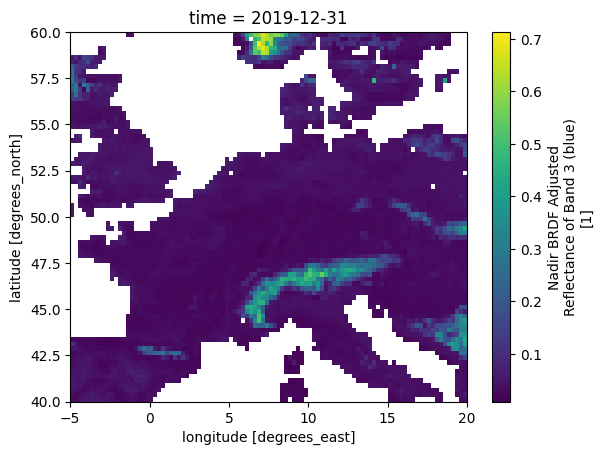

In [ ]:
# A quick way to plot using xarray

ds_area.nbar_blue.plot()

/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


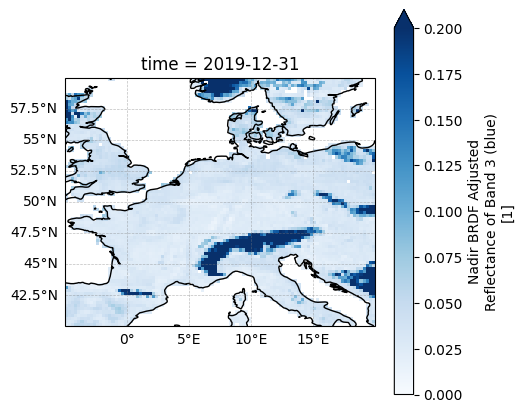

In [ ]:
# You can change some properties to make your plots more "presentable"  (see documentation : https://docs.xarray.dev/en/latest/user-guide/plotting.html)

fig = plt.figure(figsize=(5,5))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.coastlines()
gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                  linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False
gl.bottom_labels = True
gl.left_labels = True
ds_area.nbar_blue.plot(cmap='Blues', vmin=0, vmax=0.2, ax=ax,
                       transform=ccrs.PlateCarree())

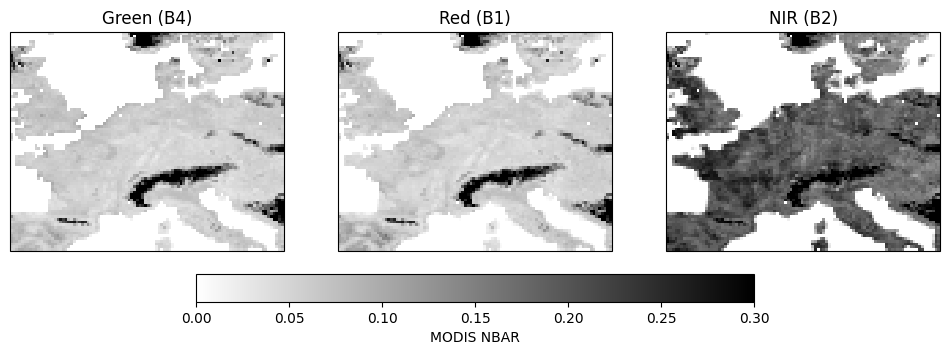

In [ ]:
# We can make a subplots

fig, axs = plt.subplots(1, 3, figsize=(12, 6), subplot_kw={'projection': ccrs.PlateCarree()})

ds_area.nbar_green.plot(cmap='binary', vmin=0, vmax=0.3, ax=axs[0], transform=ccrs.PlateCarree(), add_colorbar=False)
img = ds_area.nbar_red.plot(cmap='binary', vmin=0, vmax=0.3, ax=axs[1], transform=ccrs.PlateCarree(), add_colorbar=False)
ds_area.nbar_nir.plot(cmap='binary', vmin=0, vmax=0.3, ax=axs[2], transform=ccrs.PlateCarree(), add_colorbar=False)
axs[0].set_title('Green (B4)')
axs[1].set_title('Red (B1)')
axs[2].set_title('NIR (B2)')
cbar = fig.colorbar(img, orientation='horizontal', shrink=0.6, pad=0.05, ax=axs)
cbar.set_label('MODIS NBAR')


In [ ]:
# We can show the differnt land classes

ds_lc = xr.open_dataset(path_land_class)

lc_classes = ds_lc.land_cover
lc_classes

<xarray.DataArray 'land_cover' (time: 1, lat: 720, lon: 1440)> Size: 8MB
[1036800 values with dtype=int64]
Coordinates:
  * time     (time) datetime64[ns] 8B 2019-12-31
  * lat      (lat) float64 6kB -89.88 -89.62 -89.38 -89.12 ... 89.38 89.62 89.88
  * lon      (lon) float64 12kB -179.9 -179.6 -179.4 ... 179.4 179.6 179.9
Attributes:
    long_name:      Land Cover Classification
    units:          category
    flag_values:    [0 1 2 3 4 5 6 7 8 9]
    flag_meanings:  no_data crops trees shrubs/herbaceous/grassland sparse ve...

Text(0.5, 1.0, 'MODIS Land Cover classes')

/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_physical/ne_110m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


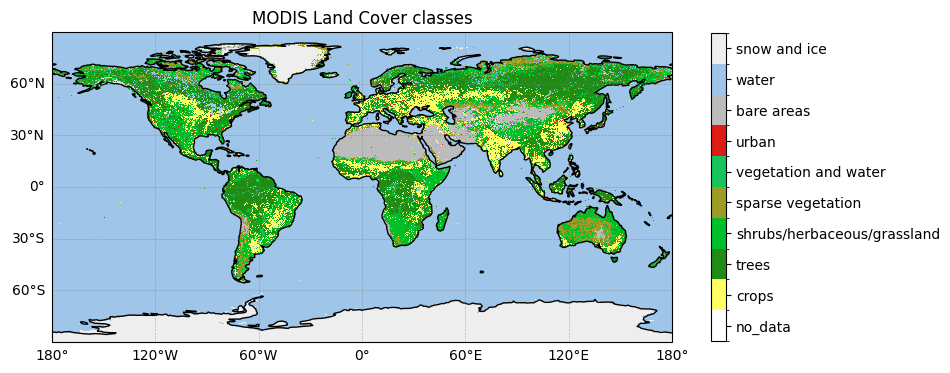

In [ ]:
# Plot land_classes over the world

from matplotlib.colors import ListedColormap, BoundaryNorm
import numpy as np

cmap_lc = ListedColormap(['#ffffff', '#ffff64', '#208c16', '#00bf29',
                          '#9c9c25', '#16c45b', '#de1b14',
                          '#bcbcbc', '#9fc5e8', '#eeeeee'])
norm = BoundaryNorm(np.arange(0,11,1), cmap_lc.N)
lccs_flags_meaning = [
            'no_data', 'crops', 'trees',
            'shrubs/herbaceous/grassland',
            'sparse vegetation', 'vegetation and water',
            'urban', 'bare areas', 'water', 'snow and ice']

fig = plt.figure(figsize=(10,10))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.coastlines()
gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                  linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False
gl.bottom_labels = True
gl.left_labels = True
img = ds_lc.land_cover.plot(cmap=cmap_lc, ax=ax,
                            add_colorbar=False, norm=norm,
                            transform=ccrs.PlateCarree())
cbar = plt.colorbar(img, shrink=0.4)
cbar.set_ticks(np.arange(0.5,10.5,1))
cbar.set_ticklabels(lccs_flags_meaning)
ax.set_title('MODIS Land Cover classes')